In [15]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Charger les données prétraitées
df = pd.read_excel('../Data/E comm.xlsx')

# Appliquer le même prétraitement que dans 02-data-preprocessing.ipynb
df.drop(columns='CustomerID', inplace=True)

# Remplir les valeurs manquantes
df['HourSpendOnApp'].fillna(df['HourSpendOnApp'].median(), inplace=True)
df['OrderAmountHikeFromlastYear'].fillna(df['OrderAmountHikeFromlastYear'].median(), inplace=True)
df['Tenure'].fillna(df['Tenure'].median(), inplace=True)
df['WarehouseToHome'].fillna(df['WarehouseToHome'].median(), inplace=True)
df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].median(), inplace=True)
df['OrderCount'].fillna(df['OrderCount'].median(), inplace=True)
df['CouponUsed'].fillna(df['CouponUsed'].median(), inplace=True)

# Encoder les variables catégorielles
from sklearn import preprocessing
for col in df.select_dtypes(include=['object']).columns:
    label_encoder = preprocessing.LabelEncoder()
    label_encoder.fit(df[col].unique())
    df[col] = label_encoder.transform(df[col])

print("Données chargées et prétraitées avec succès!")
print(f"Forme du dataset: {df.shape}")

Données chargées et prétraitées avec succès!
Forme du dataset: (5630, 19)


In [17]:
from sklearn.model_selection import train_test_split

# Select the features (X) and the target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Normalisation des caractéristiques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données d'entraînement normalisées")
print(f"Forme X_train: {X_train_scaled.shape}")
print(f"Forme X_test: {X_test_scaled.shape}")
print(f"Distribution de la variable cible y_train: {np.bincount(y_train)}")
print(f"Distribution de la variable cible y_test: {np.bincount(y_test)}")

Données d'entraînement normalisées
Forme X_train: (4504, 18)
Forme X_test: (1126, 18)
Distribution de la variable cible y_train: [3741  763]
Distribution de la variable cible y_test: [941 185]


In [19]:
# Initialiser les modèles
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True)
}

# Entraîner et évaluer chaque modèle
results = {}

for name, model in models.items():
    # Entraîner le modèle
    model.fit(X_train_scaled, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Métriques
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Validation croisée
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    print(f"{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print("-" * 40)

Logistic Regression:
  Accuracy: 0.8890
  ROC AUC: 0.8713
  CV Score: 0.8719 (+/- 0.0169)
----------------------------------------
Random Forest:
  Accuracy: 0.9831
  ROC AUC: 0.9860
  CV Score: 0.9545 (+/- 0.0172)
----------------------------------------
Gradient Boosting:
  Accuracy: 0.9263
  ROC AUC: 0.9335
  CV Score: 0.9085 (+/- 0.0139)
----------------------------------------
SVM:
  Accuracy: 0.9165
  ROC AUC: 0.9393
  CV Score: 0.9070 (+/- 0.0168)
----------------------------------------


In [20]:
# Créer un DataFrame des résultats pour comparaison
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results.keys()],
    'ROC AUC': [results[model]['roc_auc'] for model in results.keys()],
    'CV Mean': [results[model]['cv_mean'] for model in results.keys()],
    'CV Std': [results[model]['cv_std'] for model in results.keys()]
})

print("Comparaison des performances des modèles:")
print(results_df.sort_values('ROC AUC', ascending=False))

Comparaison des performances des modèles:
                 Model  Accuracy   ROC AUC   CV Mean    CV Std
1        Random Forest  0.983126  0.986004  0.954489  0.008613
3                  SVM  0.916519  0.939262  0.906974  0.008384
2    Gradient Boosting  0.926288  0.933487  0.908527  0.006957
0  Logistic Regression  0.888988  0.871253  0.871892  0.008458


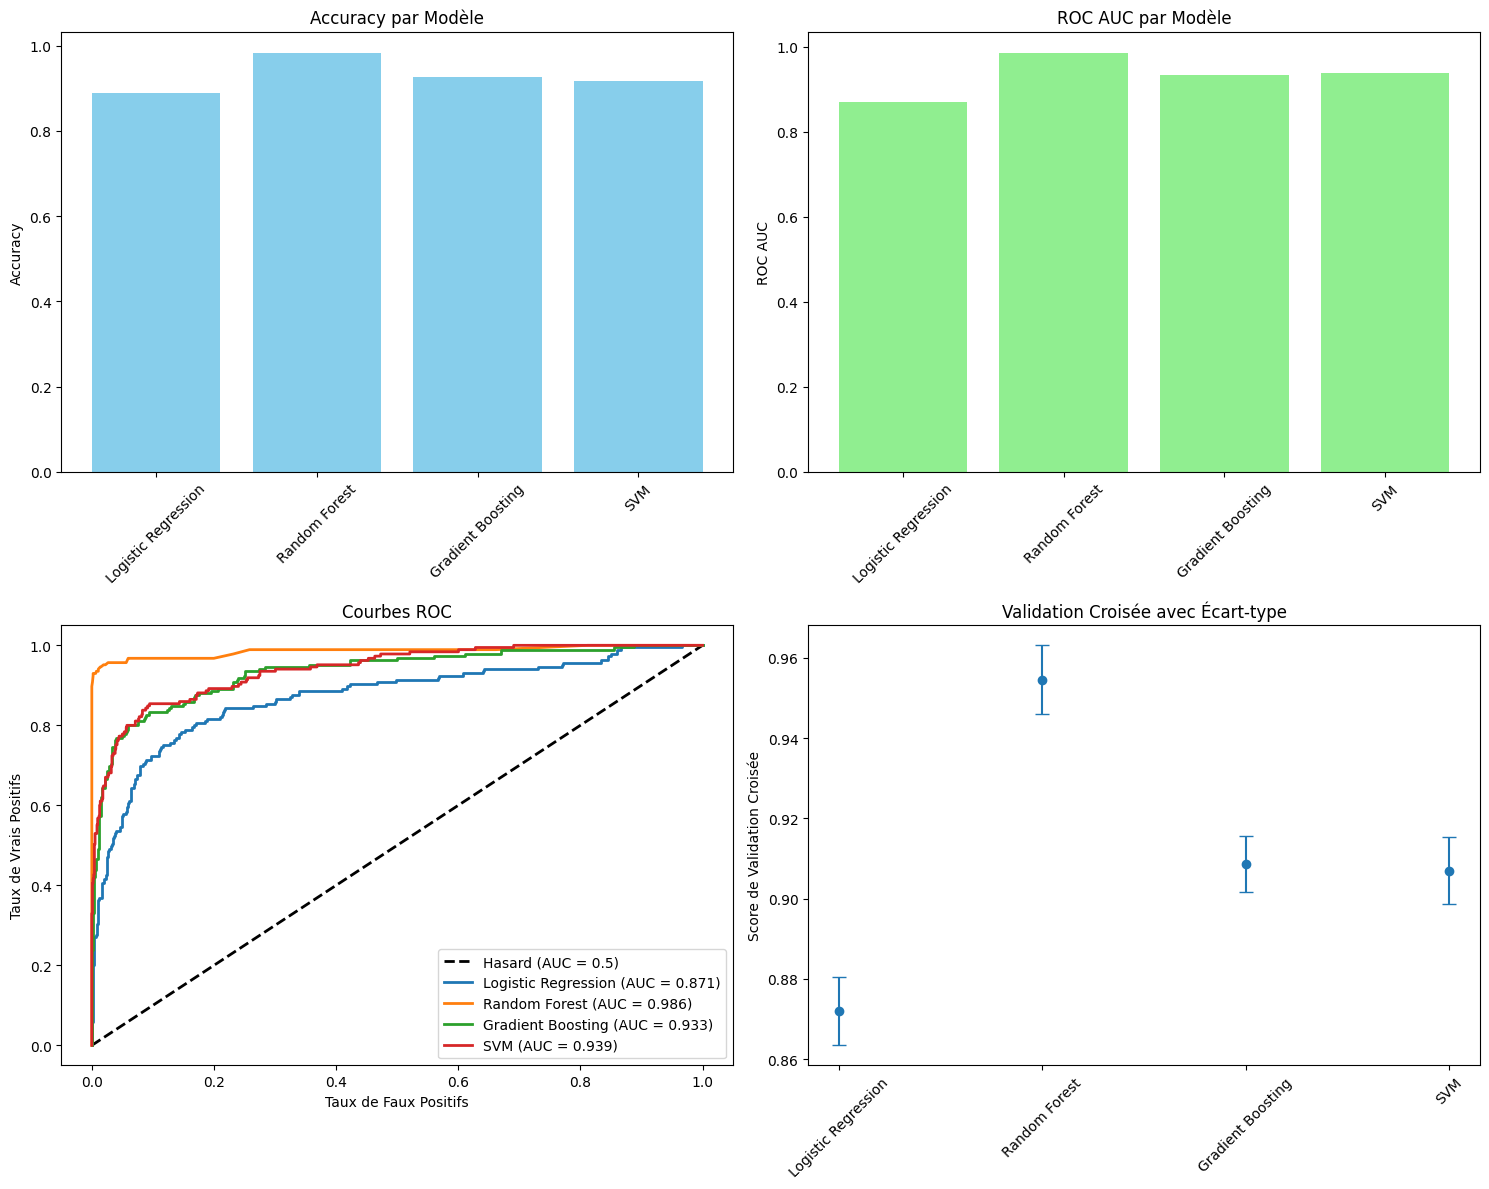

In [9]:
# Visualisation des performances des modèles
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Graphique en barres des accuracy
axes[0, 0].bar(results_df['Model'], results_df['Accuracy'], color='skyblue')
axes[0, 0].set_title('Accuracy par Modèle')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# Graphique en barres des ROC AUC
axes[0, 1].bar(results_df['Model'], results_df['ROC AUC'], color='lightgreen')
axes[0, 1].set_title('ROC AUC par Modèle')
axes[0, 1].set_ylabel('ROC AUC')
axes[0, 1].tick_params(axis='x', rotation=45)

# Courbes ROC
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=2, label='Hasard (AUC = 0.5)')
for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc = results[name]['roc_auc']
    axes[1, 0].plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')
axes[1, 0].set_xlabel('Taux de Faux Positifs')
axes[1, 0].set_ylabel('Taux de Vrais Positifs')
axes[1, 0].set_title('Courbes ROC')
axes[1, 0].legend()

# Scores de validation croisée
axes[1, 1].errorbar(range(len(results_df)), results_df['CV Mean'], 
                    yerr=results_df['CV Std'], fmt='o', capsize=5)
axes[1, 1].set_xticks(range(len(results_df)))
axes[1, 1].set_xticklabels(results_df['Model'], rotation=45)
axes[1, 1].set_ylabel('Score de Validation Croisée')
axes[1, 1].set_title('Validation Croisée avec Écart-type')

plt.tight_layout()
plt.show()

In [21]:
# Sélectionner le meilleur modèle basé sur ROC AUC
best_model_name = results_df.loc[results_df['ROC AUC'].idxmax(), 'Model']
best_model = results[best_model_name]['model']

print(f"Meilleur modèle: {best_model_name}")
print(f"ROC AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"Accuracy: {results[best_model_name]['accuracy']:.4f}")

# Rapport de classification détaillé pour le meilleur modèle
print(f"\nRapport de classification pour {best_model_name}:")
print(classification_report(y_test, results[best_model_name]['y_pred']))

Meilleur modèle: Random Forest
ROC AUC: 0.9860
Accuracy: 0.9831

Rapport de classification pour Random Forest:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       941
           1       1.00      0.90      0.95       185

    accuracy                           0.98      1126
   macro avg       0.99      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126



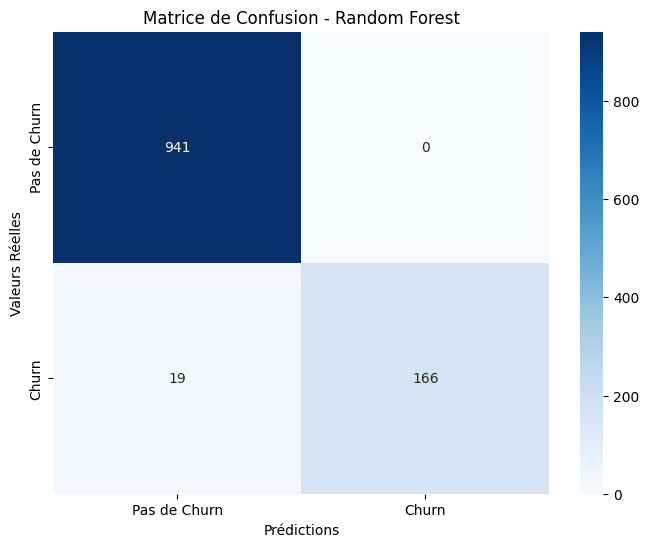

Vrais Négatifs (TN): 941
Faux Positifs (FP): 0
Faux Négatifs (FN): 19
Vrais Positifs (TP): 166
Taux de Précision: 1.0000
Taux de Rappel: 0.8973
Spécificité: 1.0000


In [11]:
# Matrice de confusion pour le meilleur modèle
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pas de Churn', 'Churn'],
            yticklabels=['Pas de Churn', 'Churn'])
plt.title(f'Matrice de Confusion - {best_model_name}')
plt.ylabel('Valeurs Réelles')
plt.xlabel('Prédictions')
plt.show()

# Calculer les métriques de la matrice de confusion
tn, fp, fn, tp = cm.ravel()
print(f"Vrais Négatifs (TN): {tn}")
print(f"Faux Positifs (FP): {fp}")
print(f"Faux Négatifs (FN): {fn}")
print(f"Vrais Positifs (TP): {tp}")
print(f"Taux de Précision: {tp/(tp+fp):.4f}")
print(f"Taux de Rappel: {tp/(tp+fn):.4f}")
print(f"Spécificité: {tn/(tn+fp):.4f}")

In [22]:
# Optimisation des hyperparamètres pour le meilleur modèle
if best_model_name == 'Random Forest':
    # Grid Search pour Random Forest
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    }
    
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )
    
elif best_model_name == 'Gradient Boosting':
    # Grid Search pour Gradient Boosting
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 4, 5]
    }
    
    grid_search = GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

elif best_model_name == 'Logistic Regression':
    # Grid Search pour Logistic Regression
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }
    
    grid_search = GridSearchCV(
        LogisticRegression(random_state=42),
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

else:  # SVM
    # Grid Search pour SVM
    param_grid = {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    }
    
    grid_search = GridSearchCV(
        SVC(random_state=42, probability=True),
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

print(f"Optimisation des hyperparamètres pour {best_model_name}...")
grid_search.fit(X_train_scaled, y_train)

print(f"Meilleurs paramètres: {grid_search.best_params_}")
print(f"Meilleur score CV: {grid_search.best_score_:.4f}")

# Modèle optimisé
optimized_model = grid_search.best_estimator_

Optimisation des hyperparamètres pour Random Forest...
Meilleurs paramètres: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur score CV: 0.9786


In [23]:
# Évaluation du modèle optimisé
y_pred_optimized = optimized_model.predict(X_test_scaled)
y_prob_optimized = optimized_model.predict_proba(X_test_scaled)[:, 1]

accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
roc_auc_optimized = roc_auc_score(y_test, y_prob_optimized)

print("=== COMPARAISON AVANT/APRÈS OPTIMISATION ===")
print(f"{best_model_name} Original:")
print(f"  Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  ROC AUC: {results[best_model_name]['roc_auc']:.4f}")
print()
print(f"{best_model_name} Optimisé:")
print(f"  Accuracy: {accuracy_optimized:.4f}")
print(f"  ROC AUC: {roc_auc_optimized:.4f}")
print()
print(f"Amélioration ROC AUC: {roc_auc_optimized - results[best_model_name]['roc_auc']:.4f}")

# Rapport de classification final
print(f"\n=== RAPPORT FINAL - {best_model_name} OPTIMISÉ ===")
print(classification_report(y_test, y_pred_optimized))

=== COMPARAISON AVANT/APRÈS OPTIMISATION ===
Random Forest Original:
  Accuracy: 0.9831
  ROC AUC: 0.9860

Random Forest Optimisé:
  Accuracy: 0.9831
  ROC AUC: 0.9868

Amélioration ROC AUC: 0.0008

=== RAPPORT FINAL - Random Forest OPTIMISÉ ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       941
           1       0.99      0.90      0.95       185

    accuracy                           0.98      1126
   macro avg       0.99      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126



In [24]:
# Sauvegarde du modèle final
import joblib

# Sauvegarder le modèle optimisé et le scaler
joblib.dump(optimized_model, '../models/best_churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Modèle et scaler sauvegardés avec succès!")
print("Fichiers créés:")
print("- ../models/best_churn_model.pkl")
print("- ../models/scaler.pkl")

# Créer un résumé des performances finales
final_summary = {
    'model_name': best_model_name,
    'best_params': grid_search.best_params_,
    'test_accuracy': accuracy_optimized,
    'test_roc_auc': roc_auc_optimized,
    'cv_score': grid_search.best_score_
}

print(f"\n=== RÉSUMÉ FINAL ===")
for key, value in final_summary.items():
    print(f"{key}: {value}")

Modèle et scaler sauvegardés avec succès!
Fichiers créés:
- ../models/best_churn_model.pkl
- ../models/scaler.pkl

=== RÉSUMÉ FINAL ===
model_name: Random Forest
best_params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
test_accuracy: 0.9831261101243339
test_roc_auc: 0.9868426343452911
cv_score: 0.9786131430239164
